In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from sklearn.model_selection import KFold

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
crop=pd.read_csv('/content/Crop_Recommendation.csv')

**Data Preprocessing**

In [ ]:
crop.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [ ]:
crop.tail()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,Coffee


In [ ]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
crop.shape

(2200, 8)

In [ ]:
crop.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
row_dup=crop[crop.duplicated()]

In [ ]:
row_dup

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop


In [ ]:
col_dup=crop.columns[crop.columns.duplicated()]

In [ ]:
col_dup

Index([], dtype='object')

In [ ]:
crop.isnull()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
2195,False,False,False,False,False,False,False,False
2196,False,False,False,False,False,False,False,False
2197,False,False,False,False,False,False,False,False
2198,False,False,False,False,False,False,False,False


In [ ]:
crop.isnull().sum()

,0
Nitrogen,0
Phosphorus,0
Potassium,0
Temperature,0
Humidity,0
pH_Value,0
Rainfall,0
Crop,0


In [ ]:
crop.shape

(2200, 8)

In [ ]:
num_col=crop.select_dtypes(include ="number")
cat_col=crop.select_dtypes(include ="object")

In [ ]:
print("Numerical columns are")
num_cols=num_col.columns.tolist()
print(num_cols)

print("Categorical columns are")
cat_cols=cat_col.columns.tolist()
print(cat_cols)

Numerical columns are
['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']
Categorical columns are
['Crop']


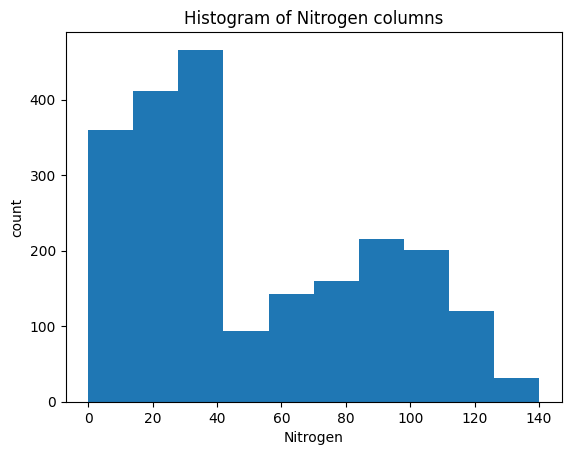

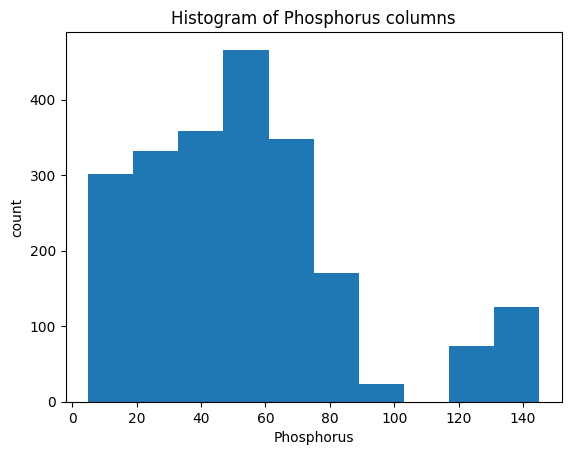

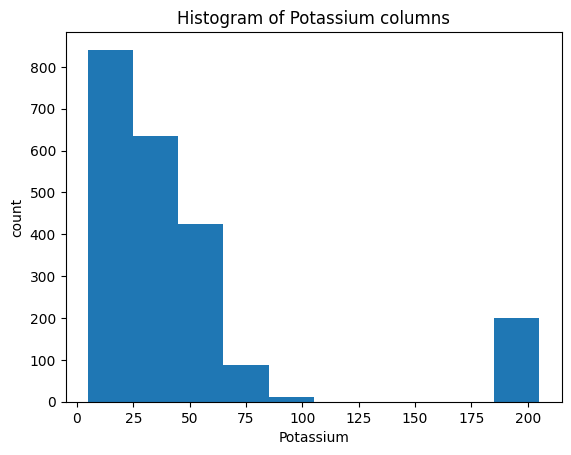

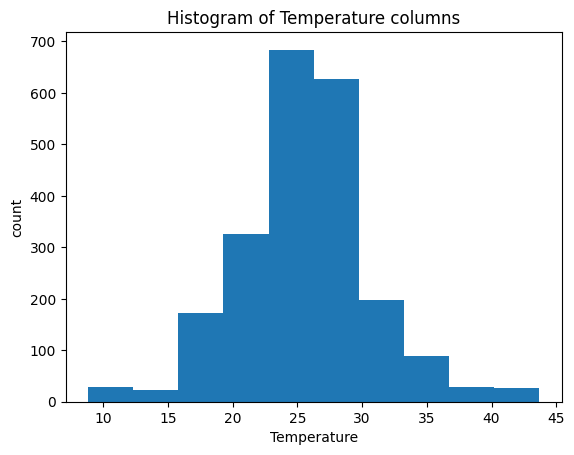

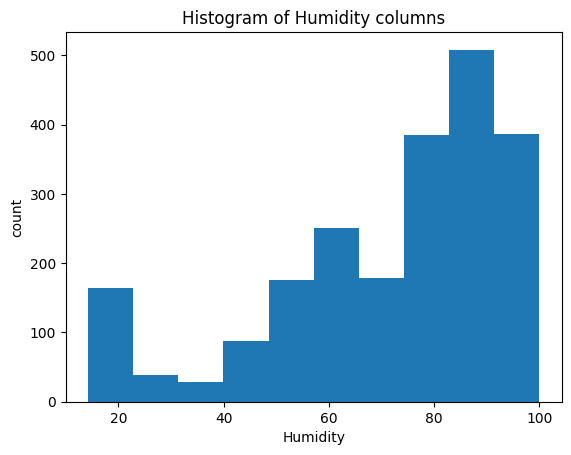

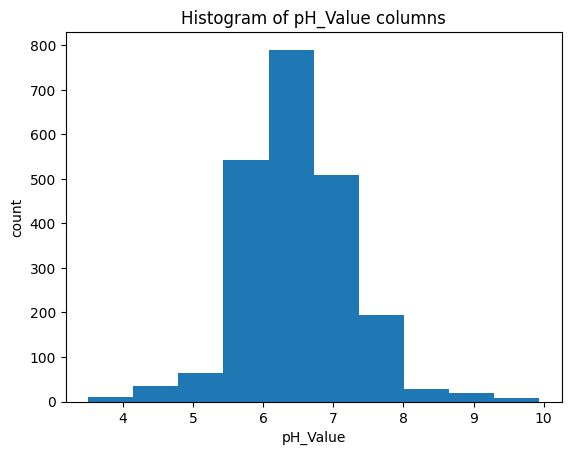

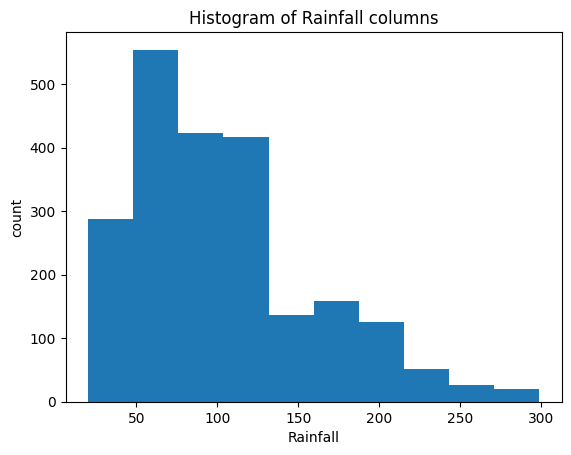

In [ ]:
for col in num_cols:
  plt.hist(num_col[col])
  plt.title("Histogram of {} columns".format(col))
  plt.xlabel(col)
  plt.ylabel("count")
  plt.show()

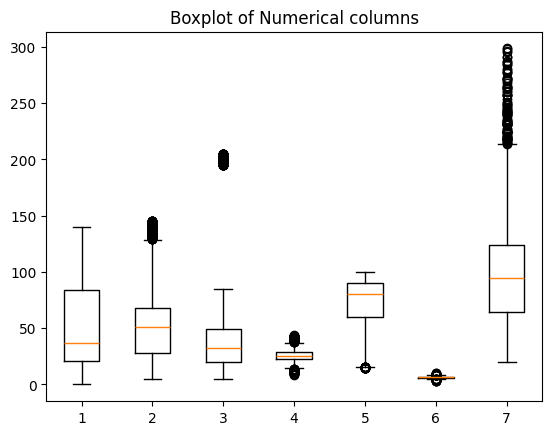

In [ ]:
plt.boxplot(num_col)
plt.title("Boxplot of Numerical columns")
plt.show()

In [ ]:
def remove_outliers(df,column_name):
  q1=df[column_name].quantile(0.25)
  q3=df[column_name].quantile(0.75)
  iqr=q3-q1
  upper_bound=q3+1.5*iqr
  lower_bound=q1-1.5*iqr
  df[column_name]=df[column_name].clip(upper=upper_bound)
  df[column_name]=df[column_name].clip(lower=lower_bound)
  return df[column_name]


In [ ]:
for col in num_cols:
  num_col[col]=remove_outliers(num_col,col)

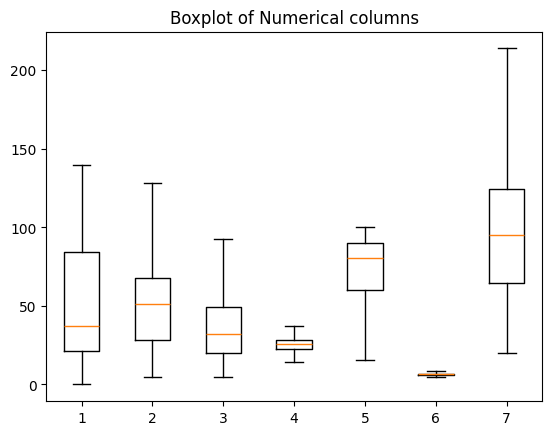

In [ ]:
plt.boxplot(num_col)
plt.title("Boxplot of Numerical columns")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=crop['Crop'])
plt.xticks(rotation=90)
plt.show()


NameError: name 'crop' is not defined

**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to your numerical features and transform them
scaled_data = scaler.fit_transform(num_col)

# Create a new DataFrame with the scaled features
scaled_df = pd.DataFrame(scaled_data, columns=num_cols, index=num_col.index)

# Concatenate the scaled numerical features with the categorical features (if any)
final_df = pd.concat([scaled_df, cat_col], axis=1)

In [ ]:
scaled_df

In [ ]:
final_df

**spliting**

In [ ]:
# Assuming 'final_df' is your DataFrame with features and target variable
X = final_df.drop('Crop', axis=1)  # Replace 'target_variable_column' with your actual target column name
y = final_df['Crop']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Adjust test_size and

**Kfold**

In [ ]:
kf = KFold(n_splits=4, shuffle=True, random_state=42)  # Create a KFold object

accuracy_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

    model = LogisticRegression()  # Create and train your model
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)  # Make predictions on the validation set

    accuracy = accuracy_score(y_val, y_pred)  # Calculate accuracy
    accuracy_scores.append(accuracy)

average_accuracy = np.mean(accuracy_scores)  # Average accuracy across all folds
print(f"Average Accuracy: {average_accuracy}")

**Models used**

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred =lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy}")


In [ ]:

sv_model = SVC(kernel='linear')
sv_model.fit(X_train, y_train)
y_pred = sv_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


In [ ]:
# Create a Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = nb_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")



In [ ]:
# Create a Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42) # You can specify hyperparameters here

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = dt_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")



In [ ]:
# Create a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # Adjust hyperparameters as needed

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")



In [ ]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Define models
models = {
    "LogisticRegression":LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel='linear'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Store precision, recall, and F1-score
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    }

# Convert results to DataFrame
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)


**Hyperparameter tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

# Assuming X_train, y_train are your training data


In [ ]:
# Define the parameter grid for Gaussian Naive Bayes
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-5, 1e-7, 1e-6, 1e-5]  # Explore different values for var_smoothing
}

In [ ]:
# Create a Gaussian Naive Bayes object
nb_model = GaussianNB()

# Create a GridSearchCV object
grid_search_nb = GridSearchCV(estimator=nb_model, param_grid=param_grid_nb, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to the training data
grid_search_nb.fit(X_train, y_train)

# Get the best hyperparameters and the best score
best_params_nb = grid_search_nb.best_params_
best_score_nb = grid_search_nb.best_score_

# Print the best hyperparameters and score
print("Best Hyperparameters for Naive Bayes:", best_params_nb)
print("Best Score for Naive Bayes:", best_score_nb)

# Now you can use the best hyperparameters to train your final Naive Bayes model:
best_nb_model = GaussianNB(**best_params_nb)
best_nb_model.fit(X_train, y_train)

# Evaluate the final Naive Bayes model on the test data (X_test, y_test)
# ...

**Confusion matrix **

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
cm = confusion_matrix(y_test, y_pred)


In [ ]:
# Plot confusion matrix using seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
print(classification_report(y_test, y_pred))


**Pickle File Creation**


In [ ]:
import pickle

For Naive Bayes

In [ ]:
filename='nb_model.pkl'
with open(filename,'wb') as file:
  pickle.dump(nb_model,file)


In [ ]:
with open(filename,'rb') as f:
  nb_model=pickle.load(f)

In [ ]:
pred=best_nb_model.predict(np.array([[6,5,7,9,8,2,4]]))

In [ ]:
pred[0]

**For Logistic Regression**

In [ ]:
filename='lr_model.pkl'
with open(filename,'wb') as file:
  pickle.dump(lr_model,file)

In [ ]:
with open(filename,'rb') as f:
  lr_model=pickle.load(f)

In [ ]:
pred=lr_model.predict(np.array([[6,5,7,9,8,2,4]]))

In [ ]:
pred[0]

**For K-Nearest Neighbor**

In [ ]:
filename='knn_model.pkl'
with open(filename,'wb') as file:
  pickle.dump(knn,file)

In [ ]:
with open(filename,'rb') as f:
  knn=pickle.load(f)

In [ ]:
pred=knn.predict(np.array([[4,5,6,7,8,9,1]]))

In [ ]:
pred[0]